# CODE

### Instalamos Requirements

In [ ]:
# Instalar la librería de kagglehub
!pip install kagglehub pandas

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

### Descargamos el dataset

In [ ]:
# Descargamos el dataset (si ya lo bajó, usará la caché, no tarda nada)
path = kagglehub.dataset_download("rockbottom73/leads-dataset")

# Buscamos el archivo
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    csv_path = os.path.join(path, csv_files[0])

    # --- AQUÍ ESTÁ EL CAMBIO ---
    # Añadimos encoding='latin-1' para evitar el error de Unicode
    try:
        df = pd.read_csv(csv_path, encoding="latin-1")
        print("✅ Archivo cargado correctamente con encoding Latin-1")
    except:
        # Si falla, probamos con 'cp1252' (otro formato común de Windows)
        df = pd.read_csv(csv_path, encoding="cp1252")
        print("✅ Archivo cargado correctamente con encoding CP1252")

    # Mostramos información básica
    print("\n--- PRIMER VISTAZO ---")
    print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
    print("\nPrimeras 5 filas:")
    display(df.head())

    print("\n--- TIPOS DE DATOS ---")
    print(df.info())

else:
    print("❌ Error: No se encontró ningún archivo .csv")

100%|██████████| 994k/994k [00:00<00:00, 58.9MB/s]

Extracting files...


✅ Archivo cargado correctamente con encoding Latin-1

--- PRIMER VISTAZO ---
Filas: 9240, Columnas: 122

Primeras 5 filas:


/tmp/ipython-input-1365079656.py:13: DtypeWarning: Columns (5,44,53,77,97) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, encoding="latin-1")


,Prospect ID,Lead Number,Company,Lead Origin,Mobile Number,Website,Time Zone,Job Title,Lead Source,Source Medium,...,Stage Rotting Flag Level,Mailing Preferences,Twitter Id,Facebook Id,LinkedIn Id,Skype Id,Gtalk Id,Google Plus Id,Quality Score 01,Groups
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,NaN,API,NaN,NaN,NaN,NaN,Olark Chat,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,NaN,API,NaN,NaN,NaN,NaN,Organic Search,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,NaN,Landing Page Submission,NaN,NaN,NaN,NaN,Direct Traffic,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,NaN,Landing Page Submission,NaN,NaN,NaN,NaN,Direct Traffic,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3256f628-e534-4826-9d63-4a8b88782852,660681,NaN,Landing Page Submission,NaN,NaN,NaN,NaN,Google,CPC,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- TIPOS DE DATOS ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Columns: 122 entries, Prospect ID to Groups
dtypes: float64(34), int64(3), object(85)
memory usage: 8.6+ MB
None


Columnas:

In [ ]:
for col in df.columns:
    print(col)

Prospect ID
Lead Number
Company
Lead Origin
Mobile Number
Website
Time Zone
Job Title
Lead Source
Source Medium
Notes
Source Campaign
Source Content
Do Not Email
Do Not Call
Lead Stage
Lead Grade
Lead Score
Order Value
Engagement Score
TotalVisits
Page Views Per Visit
Average Time Per Visit
Last Activity
Last Activity Date
Related Landing Page Id
First Landing Page Submission Id
First Landing Page Submission Date
Created On
Modified On
Lead Conversion Date
Address 1
Address 2
Cityold
State
Country
Zip
Facebook URL
Twitter URL
LinkedIn URL
Industry
Work Area
Course Interested
Keyword
Date
Specialization
Entrance Test
How did you hear about SomeSchool
What is your current occupation
If you are a working professional
If you are a working professional please mention 
What matters most to you in choosing an ADP
Age
Next Follow Up
Search
Magazine
Newspaper Article
Welearn Forums
Newspaper
Digital Advertisement
Through Recommendations
Any other Please specify
Last Degree
Receive More Updates 

In [ ]:
# 1. Verificamos valores nulos (vacíos)
null_percentages = df.isnull().sum() / len(df) * 100

# 2. Filtramos: Nos quedamos solo con columnas que tengan MENOS del 40% de datos vacíos
# (Un umbral del 30-40% es estándar en TFGs)
cols_to_keep = null_percentages[null_percentages < 40].index
df_clean = df[cols_to_keep].copy()

print(f"📉 Hemos pasado de {df.shape[1]} columnas a {df_clean.shape[1]} columnas.")

# 3. Buscamos cuál es la variable objetivo (Target)
# En este dataset suele llamarse 'Converted', 'Status' o similar.
# Vamos a imprimir las columnas restantes para identificarla.
print("\n--- COLUMNAS RESTANTES ---")
print(df_clean.columns.tolist())


📉 Hemos pasado de 122 columnas a 59 columnas.

--- COLUMNAS RESTANTES ---
['Prospect ID', 'Lead Number', 'Lead Origin', 'Lead Source', 'Do Not Email', 'Do Not Call', 'Lead Stage', 'Lead Score', 'Engagement Score', 'TotalVisits', 'Page Views Per Visit', 'Average Time Per Visit', 'Last Activity', 'Last Activity Date', 'Created On', 'Modified On', 'Lead Conversion Date', 'Cityold', 'Country', 'Specialization', 'Entrance Test', 'How did you hear about SomeSchool', 'What is your current occupation', 'If you are a working professional', 'If you are a working professional please mention ', 'What matters most to you in choosing an ADP', 'Age', 'Search', 'Magazine', 'Newspaper Article', 'Welearn Forums', 'Newspaper', 'Digital Advertisement', 'Through Recommendations', 'Receive More Updates About Our Courses', 'Tags', 'Update me on Supply Chain Content', 'Get updates on PGDMHBSCM', 'Lead Profile', 'City New', 'Country New', 'Industry New', 'I agree to pay the amount through cheque', 'Previous St

Primero hay que saber el 'target', igual no hay uno fijo y es la combinación de varias variables...

In [ ]:
# Lista de columnas sospechosas de ser el Target
candidatas = ['Lead Stage', 'Lead Quality', 'Lead Conversion Date', 'Admission Date']

print("--- INVESTIGANDO EL TARGET ---\n")

for col in candidatas:
    if col in df_clean.columns:
        print(f"🔹 VALORES EN: '{col}'")
        # Mostramos los 10 valores más comunes
        print(df_clean[col].value_counts(dropna=False).head(10))
        print("-" * 30 + "\n")
    else:
        print(f"⚠️ La columna '{col}' no existe en el DataFrame (quizás se borró en la limpieza previa?)\n")

--- INVESTIGANDO EL TARGET ---

🔹 VALORES EN: 'Lead Stage'
Lead Stage
Qualified         2960
Unreachable       2763
Junk Lead         1686
Not Interested     899
Closed             525
Not Eligible       293
Interested          76
Lost                29
Not Called           9
Name: count, dtype: int64
------------------------------

⚠️ La columna 'Lead Quality' no existe en el DataFrame (quizás se borró en la limpieza previa?)

🔹 VALORES EN: 'Lead Conversion Date'
Lead Conversion Date
NaN                 2527
16-07-2016 13:13       3
19-05-2016 6:40        3
08-06-2016 10:23       3
16-07-2016 10:01       3
20-05-2016 11:27       3
20-06-2016 10:58       3
21-06-2016 12:34       3
20-05-2016 8:34        3
20-05-2016 7:31        3
Name: count, dtype: int64
------------------------------

⚠️ La columna 'Admission Date' no existe en el DataFrame (quizás se borró en la limpieza previa?)



### Reorganizamos el dataset

In [ ]:
# ==========================================
# 3. CREACIÓN DEL TARGET (OBJETIVO)
# ==========================================
# Definimos qué es un "Lead Exitoso" (1) y qué no (0)
def categorizar_target(stage):
    positivos = ['Closed', 'Qualified', 'Interested']
    if stage in positivos:
        return 1
    return 0

# Creamos la columna Target
df_clean['Target'] = df_clean['Lead Stage'].apply(categorizar_target)
print(f"🎯 Target creado. Distribución: \n{df_clean['Target'].value_counts()}")

# ==========================================
# 4. LIMPIEZA Y SELECCIÓN DE VARIABLES
# ==========================================
# Lista combinada de todo lo que vamos a borrar:
# - Identificadores (IDs)
# - Data Leakage (información del futuro)
# - Columnas con demasiados valores únicos (que explotaban la memoria)
cols_to_drop = [
    # IDs y Texto Inútil
    'Prospect ID', 'Lead Number', 'Facebook URL', 'Twitter URL', 'LinkedIn URL',
    'Photo Url', 'Notes', 'Tags', 'Address 1', 'Address 2', 'Cityold', 'City New',

    # Data Leakage / Redundante con Target
    'Lead Stage', 'Lead Quality', 'Lead Conversion Date', 'Admission Date',
    'Last Activity Date', 'First Landing Page Submission Date', 'Modified On',
    'Created On', 'Asymmetrique Activity Index', 'Asymmetrique Profile Index',

    # "Culpables" de la explosión de columnas (Alta cardinalidad)
    'Last Visit Date', 'Last Notable Activity Date', 'First Landing Page Submission Id',
    'Admission Number', 'Last Degree', 'Company', 'Mobile Number', 'Website',
    'Source Referrer', 'Source Campaign', 'Lead Source', 'Specialization',
    'ecode', 'Last Activity', 'Country', 'State'
]

# Borramos solo las que existan
existing_cols = [c for c in cols_to_drop if c in df_clean.columns]
df_clean = df_clean.drop(columns=existing_cols)
print(f"🧹 Columnas borradas. Dimensiones finales: {df_clean.shape}")

🎯 Target creado. Distribución: 
Target
0    5679
1    3561
Name: count, dtype: int64
🧹 Columnas borradas. Dimensiones finales: (9240, 44)


In [ ]:
# ==========================================
# 5. PREPROCESAMIENTO (ENCODING)
# ==========================================
# Convertimos todo el texto restante a números (One-Hot Encoding)
df_model = pd.get_dummies(df_clean, drop_first=True)
df_model = df_model.fillna(0) # Rellenamos huecos con 0

print(f"📉 Dimensiones finales para el modelo: {df_model.shape}")

# Separamos Datos (X) y Objetivo (y)
X = df_model.drop('Target', axis=1)
y = df_model['Target']

# Dividimos: 80% Entrenar, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalamos los datos (Importante para Regresión Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

📉 Dimensiones finales para el modelo: (9240, 196)



🤖 Entrenando Regresión Logística...

RESULTADOS DEL MODELO (BASELINE)
✅ Accuracy (Exactitud Global): 87.01%

--- Informe de Clasificación ---
              precision    recall  f1-score   support

           0       0.91      0.87      0.89      1107
           1       0.82      0.87      0.84       741

    accuracy                           0.87      1848
   macro avg       0.86      0.87      0.87      1848
weighted avg       0.87      0.87      0.87      1848



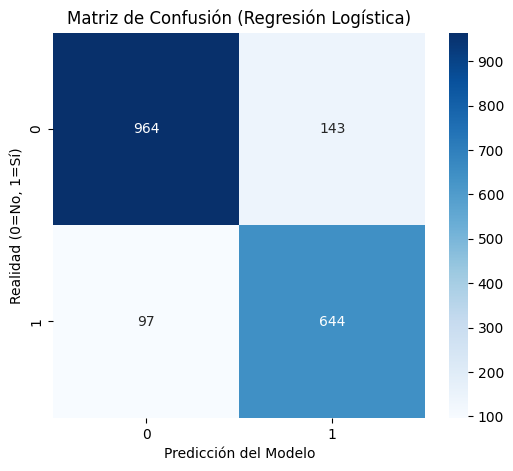

In [ ]:
# ==========================================
# 6. ENTRENAMIENTO Y EVALUACIÓN
# ==========================================
print("\n🤖 Entrenando Regresión Logística...")
log_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

# Predicción
y_pred = log_model.predict(X_test_scaled)

# Resultados
print("\n" + "="*40)
print("RESULTADOS DEL MODELO (BASELINE)")
print("="*40)
print(f"✅ Accuracy (Exactitud Global): {accuracy_score(y_test, y_pred):.2%}\n")
print("--- Informe de Clasificación ---")
print(classification_report(y_test, y_pred))

# Gráfico de la Matriz de Confusión
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión (Regresión Logística)')
plt.ylabel('Realidad (0=No, 1=Sí)')
plt.xlabel('Predicción del Modelo')
plt.show()

In [ ]:

# 1. RANDOM FOREST
print("🌲 Entrenando Random Forest...")
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)

# 2. XGBOOST (El favorito de Kaggle)
print("🚀 Entrenando XGBoost...")
# XGBoost no usa class_weight='balanced' igual que sklearn, usa scale_pos_weight
# Calculamos el ratio: (negativos / positivos)
ratio = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = XGBClassifier(scale_pos_weight=ratio, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

# 3. TABLA DE RESULTADOS FINAL
print("\n" + "="*40)
print("🏆 TORNEO DE MODELOS")
print("="*40)
print(f"1️⃣ Regresión Logística: {0.8701:.2%}") # Pongo el dato que ya tenías
print(f"2️⃣ Random Forest:       {acc_rf:.2%}")
print(f"3️⃣ XGBoost:             {acc_xgb:.2%}")

if acc_xgb > 0.8701 or acc_rf > 0.8701:
    print("\n✅ Conclusión: ¡Los modelos complejos han mejorado el resultado!")
else:
    print("\n⚠️ Conclusión: El modelo simple aguanta el tipo (esto es muy interesante académicamente).")

🌲 Entrenando Random Forest...
🚀 Entrenando XGBoost...

🏆 TORNEO DE MODELOS
1️⃣ Regresión Logística: 87.01%
2️⃣ Random Forest:       87.77%
3️⃣ XGBoost:             87.61%

✅ Conclusión: ¡Los modelos complejos han mejorado el resultado!


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

print("🧠 Configurando Red Neuronal (Deep Learning)...")

# 1. ARQUITECTURA DE LA RED
# Entrada: Número de columnas (196 características)
# Capas Ocultas: 64 neuronas -> 32 neuronas
# Salida: 1 neurona (probabilidad de ser Lead Exitoso)
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3), # Apaga el 30% de neuronas al azar para evitar memorizar

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid') # Sigmoid es obligatorio para salida binaria (0 o 1)
])

# 2. COMPILACIÓN
# Usamos 'binary_crossentropy' porque es sí/no
# Learning rate ajustado para que aprenda despacio y bien
optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# 3. ENTRENAMIENTO
# Epochs = 50 (cuántas veces repasa los datos)
# Batch size = 32 (cuántos exámenes corrige antes de aprender)
print("⏳ Entrenando Red Neuronal (esto puede tardar unos segundos)...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2, # Usa un trocito para validarse a sí misma
    verbose=0 # Ponemos 0 para que no llene la pantalla de texto
)

# 4. EVALUACIÓN
y_pred_nn_prob = model.predict(X_test_scaled)
# La red devuelve probabilidades (ej: 0.85), convertimos a 1 o 0
y_pred_nn = (y_pred_nn_prob > 0.5).astype(int)

acc_nn = accuracy_score(y_test, y_pred_nn)

print("\n" + "="*40)
print("COMPARATIVA FINAL (INCLUYENDO DEEP LEARNING)")
print("="*40)
print(f"1️⃣ Regresión Logística: {0.8701:.2%}")
print(f"2️⃣ Random Forest:       {0.8777:.2%}")
print(f"3️⃣ XGBoost:             {0.8761:.2%}")
print(f"4️⃣ Deep Learning (NN):  {acc_nn:.2%}")

if acc_nn < 0.8777:
    print("\n✅ Hipótesis del profesor confirmada: Deep Learning no supera a Random Forest en estos datos.")
else:
    print("\n🚀 ¡Sorpresa! Deep Learning ha funcionado mejor de lo esperado.")

🧠 Configurando Red Neuronal (Deep Learning)...
⏳ Entrenando Red Neuronal (esto puede tardar unos segundos)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

COMPARATIVA FINAL (INCLUYENDO DEEP LEARNING)
1️⃣ Regresión Logística: 87.01%
2️⃣ Random Forest:       87.77%
3️⃣ XGBoost:             87.61%
4️⃣ Deep Learning (NN):  88.85%

🚀 ¡Sorpresa! Deep Learning ha funcionado mejor de lo esperado.


### ¿Y si probamos más modelos aún y los comparamos? Lo más probable es que no haya ninguno increíble pero por ver los baseline que tenemos...

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training SVM (Kernel RBF)...
Training K-Nearest Neighbors...
Training Decision Tree...
Training AdaBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Training Naive Bayes...

CLASIFICACIÓN FINAL
                Modelo  Accuracy  F1-Score
1        Random Forest  0.877706  0.843923
2              XGBoost  0.876082  0.847231
0  Logistic Regression  0.870130  0.842932
3     SVM (Kernel RBF)  0.851732  0.818302
5        Decision Tree  0.845779  0.808081
6             AdaBoost  0.839286  0.762590
4  K-Nearest Neighbors  0.832251  0.773392
7          Naive Bayes  0.788420  0.645512


/tmp/ipython-input-345329224.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Modelo", data=results_df, palette="viridis")


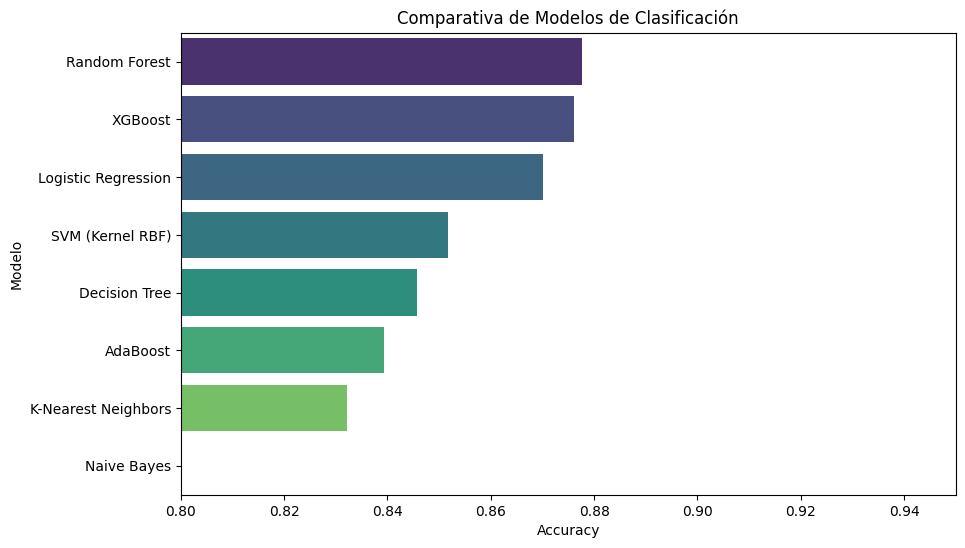


Recuerda: Tu Deep Learning dio aprox: 88.85%


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score

# 1. DEFINIMOS LOS CONTENDIENTES
# Diccionario con nombre del modelo e instancia
modelos = {
    "Logistic Regression": log_model,          # El que ya tenías
    "Random Forest":       rf_model,           # El que ya tenías
    "XGBoost":             xgb_model,          # El que ya tenías
    "SVM (Kernel RBF)":    SVC(probability=True, random_state=42), # Potente pero lento
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),      # Simple
    "Decision Tree":       DecisionTreeClassifier(random_state=42),  # Árbol simple (suele overfittear)
    "AdaBoost":            AdaBoostClassifier(algorithm='SAMME', random_state=42), # Boosting clásico
    "Naive Bayes":         GaussianNB()                              # Probabilístico
}

resultados = []

# 2. BUCLE DE ENTRENAMIENTO
for nombre, modelo in modelos.items():
    print(f"Training {nombre}...")
    try:
        # Entrenamos
        modelo.fit(X_train_scaled, y_train)

        # Predecimos
        y_pred = modelo.predict(X_test_scaled)

        # Guardamos métricas
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        resultados.append({
            "Modelo": nombre,
            "Accuracy": acc,
            "F1-Score": f1
        })
    except Exception as e:
        print(f"⚠️ Falló {nombre}: {e}")

# 3. VISUALIZACIÓN DEL RANKING
results_df = pd.DataFrame(resultados).sort_values(by="Accuracy", ascending=False)

print("\n" + "="*40)
print("CLASIFICACIÓN FINAL")
print("="*40)
print(results_df)

# Gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy", y="Modelo", data=results_df, palette="viridis")
plt.title("Comparativa de Modelos de Clasificación")
plt.xlim(0.8, 0.95) # Hacemos zoom en la parte importante (80% - 95%)
plt.show()

# Añadimos la Red Neuronal (que calculamos antes) manualmente a la tabla para comparar
print(f"\nRecuerda: Tu Deep Learning dio aprox: {acc_nn:.2%}")